# Analyses of drug data from group #6

To do
- ~~Analyze lick data~~
    - ~~RT~~
    - ~~Lick rate~~
    - ~~ILI~~
- History kernels
- ~~Add HMM~~
- Repeating bias per ILD

In [1]:
# Standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel

# Own
from glue_sessions.glue_sessions import *
from intersession import glue_animals_intersessions
from my_fun import *
from licks.licks import *
from psychometric_curves import *
from kernels.psychophysical_kernels import *
from full_model_behavior import *
from drugs import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2
# %matplotlib inline
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [3]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
# sns.set_context('poster')
# sns.set_context('notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
# default_figsize = np.array(plt.rcParams['figure.figsize'])

# Load behavioral data

In [4]:
# Set parameters
experiment = '2AFC_6'  # Drug

# path_session = 'glue_sessions'  # Raw data
path_session = 'glmhmm/TEST/2s_3cov'  # GLM-HMM model

# Load trial data (lick analyses)
df_behavior = glue_animals(experiment=experiment, path_session=path_session, filter_drug=True, update=False, to_csv=False)  # Raw

# Load intersession data
df_intersessions = glue_animals_intersessions(experiment=experiment, filter_drug=True, update=False, to_csv=False)

# 0 pad subject ID (this batches start with 0 so IDs are read as ints instead of 3 character length str)
df_behavior.Subject = df_behavior.Subject.astype(str)
df_behavior['Subject'] = df_behavior['Subject'].str.zfill(3)
df_intersessions.Subject = df_intersessions.Subject.astype(str)
df_intersessions['Subject'] = df_intersessions['Subject'].str.zfill(3)

# Filter data

In [5]:
animals = main([experiment])[experiment]  # Pick good cherries

# Remove subjects not in cherries
df_behavior = df_behavior[df_behavior.Subject.isin(animals)].reset_index(drop=True)
df_intersessions = df_intersessions[df_intersessions.Subject.isin(animals)].reset_index(drop=True)

if path_session == 'glue_sessions':  # GLM-HMM data is already filtered
    df_behavior = filter_behavior(df_behavior, clean_start=True, drop_miss=False, filter_drug=True)  # Gonna analyze misses
print(f'{len(df_behavior)} trials')

Cherry picking for experiment: 2AFC_6
Number of responded trials in data collection (with evidences):
11: 0 trials
14: 10896 trials
15: 3739 trials
16: 11058 trials
17: 12772 trials
18: 7451 trials
19: 8305 trials
20: 10752 trials
21: 0 trials
22: 10453 trials
23: 10169 trials
24: 10118 trials
25: 9890 trials


Subjects left behind (never learnt):
11: 0 trials
21: 0 trials


Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 1562 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2060 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2401 trials from session start (AW and Warm Up trials)
Tota

In [6]:
# # Remove bad sessions
#
# # Add paired session index
# n_paired_sessions = len(df_intersessions) // 2
# print(f'Total: {n_paired_sessions:.0f} paired sessions')
# paired_sessions = np.repeat(np.arange(n_paired_sessions), 2)
# df_intersessions['PairedSession'] = paired_sessions
#
# print(df_intersessions.loc[df_intersessions.PairedSession.isin, ['PairedSession', 'Accuracy', 'AccuracyLeft', 'AccuracyRight']])
#
# threshold = 0.5  # Accuracy threshold. Drop in accuracy expected, use very lax value
# mask = df_intersessions.Accuracy < threshold
# # mask = ((df_intersessions.AccuracyLeft < threshold) | (df_intersessions.AccuracyRight < threshold))
#
# # Remove from intersession data
# bad_sessions = df_intersessions[mask].PairedSession
# bad_sessions = bad_sessions.unique()
# print(f'{len(bad_sessions)} bad paired sessions. Pair indexes: {bad_sessions}')
# print(df_intersessions.loc[df_intersessions.PairedSession.isin(bad_sessions), ['PairedSession', 'Accuracy', 'AccuracyLeft', 'AccuracyRight']])
# df_intersessions = df_intersessions[~df_intersessions.PairedSession.isin(bad_sessions)].reset_index(drop=True)
# print(f'Dropped {np.round((len(bad_sessions) / n_paired_sessions)*100, 2)}% paired sessions')
#
# # Remove from trial data (merging with already filtered intersession data)
# df_behavior['Date'] = pd.to_datetime(df_behavior['Date'])
# df_behavior = df_behavior.merge(
#     df_intersessions[['Subject', 'Dates', 'PairedSession']],
#     left_on=['Subject', 'Date'],
#     right_on=['Subject', 'Dates'],
#     how='left'
# )
#
# # Optionally, drop the extra 'Date' column from df_intersession after merging
# df_behavior = df_behavior.drop(columns='Dates')

Total: 81 paired sessions


In [6]:
n_subjects = df_behavior.Subject.nunique()
n_paired_sessions = len(df_intersessions) // 2
n_trials = len(df_behavior)
n_trials_saline = len(df_behavior[df_behavior.Drug == 0])
n_trials_drug = len(df_behavior[df_behavior.Drug == 1])
print(f'N subjects = {n_subjects}')
print(f'N paired sessions = {n_paired_sessions}')
print(f'N trials = {n_trials} (saline: {n_trials_saline}, drug: {n_trials_drug})')

N subjects = 10
N paired sessions = 81
N trials = 44583 (saline: 22185, drug: 22398)


# Behavioral metrics

## Standard

AccMaxEvi: t = 6.795, p = 0.000
AccNonMaxEvi: t = 1.242, p = 0.246
LateralBias: t = -0.894, p = 0.395
AbsLatBias: t = -5.580, p = 0.000
MissRate: t = 1.474, p = 0.174
CorrRepBias: t = -4.375, p = 0.002


Text(0, 0.5, 'Rep. bias')

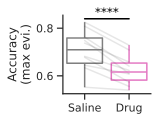

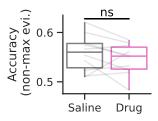

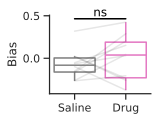

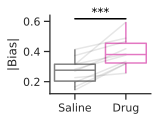

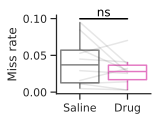

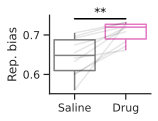

In [57]:
df_intersessions['AbsLatBias'] = abs(df_intersessions.LateralBias)  # Add new column
figsize = fig_size(n_cols=3)
# plot_var_drug(df_intersessions, var_name='Accuracy', figsize=figsize)
plot_var_drug(df_intersessions, var_name='AccMaxEvi', figsize=figsize); plt.ylabel('Accuracy\n(max evi.)')
plot_var_drug(df_intersessions, var_name='AccNonMaxEvi', figsize=figsize); plt.ylabel('Accuracy\n (non-max evi.)')
plot_var_drug(df_intersessions, var_name='LateralBias', figsize=figsize); plt.ylabel('Bias')
plot_var_drug(df_intersessions, var_name='AbsLatBias', figsize=figsize); plt.ylabel('|Bias|')
plot_var_drug(df_intersessions, var_name='MissRate', figsize=figsize); plt.ylabel('Miss rate')
plot_var_drug(df_intersessions, var_name='CorrRepBias', figsize=figsize); plt.ylabel('Rep. bias')

## Licks

In [76]:
subject = '016'  # Example mouse

### Add lick data

In [200]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Add session half index (0 for the 1st and 1 for the 2nd)
df_behavior['SessionHalf'] = (df_behavior.Trial >= df_behavior.groupby('Session').Trial.transform('max') / 2).astype(int)
# Add absolute ILD
loc = df_behavior.columns.get_loc('ILD') + 1
df_behavior.insert(loc, 'absILD', df_behavior['ILD'].abs())

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

# df_behavior.head()

Port1In or Port2In are already lists
3.47% of premature lick trials (before response window)
Port1In or Port2In are already lists
['absILD', 'SessionHalf']


### RTs

In [ ]:
# Sometimes pandas doesn't recognize all nans as actual nans. Force it and remove them
df_behavior['RT'] = pd.to_numeric(df_behavior['RT'], errors='coerce')
df_behavior = df_behavior.dropna(subset=['RT']).reset_index(drop=True)
assert len(df_behavior) == len(df_behavior['RT'].dropna().values.reshape(-1, 1))

In [ ]:
# Correct 150 ms artifact in RT
# To do: hardcode it in the lick preprocessing pipeline (add_lick_data)
df_behavior.RT -= 0.15
df_behavior.RT = df_behavior.RT.clip(lower=0)

In [226]:
median_RT_saline = df_behavior[df_behavior.Drug==0].RT.median()
mad_RT_saline = median_abs_deviation(df_behavior[df_behavior.Drug==0].RT, scale=1)
print(f'RT saline (median ± m.a.d.): {np.round(median_RT_saline, 3)} ± {np.round(mad_RT_saline, 3)} s')

median_RT_drug = df_behavior[df_behavior.Drug==1].RT.median()
mad_RT_drug = median_abs_deviation(df_behavior[df_behavior.Drug==1].RT, scale=1)
print(f'RT drug (median ± m.a.d.): {np.round(median_RT_drug, 3)} ± {np.round(mad_RT_drug, 3)} s')

RT saline (median ± m.a.d.): 0.312 ± 0.034 s
RT drug (median ± m.a.d.): 0.319 ± 0.035 s


(0.0, 0.015)

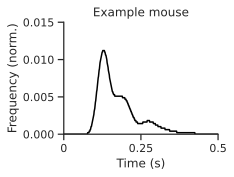

In [107]:
# Example subject
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Subject=='016'], var='RT')
plt.title('Example mouse')
print(plt.gca().get_ylim())
plt.ylim(0, 0.015)

(0.0, 0.01)

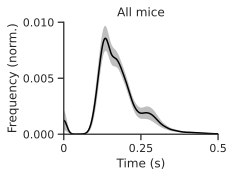

In [108]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior, var='RT', density=False)
plt.title('All mice')
print(plt.gca().get_ylim())
plt.yticks((0, 0.005, 0.01))
plt.ylim(0, 0.01)

(0.0, 0.015)

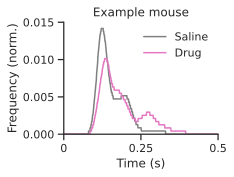

In [109]:
# Example subject
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Subject=='016'], var='RT', split='drug', kind='hist')
plt.title('Example mouse')
print(plt.gca().get_ylim())
plt.ylim(0, 0.015)

(0.0, 0.01)

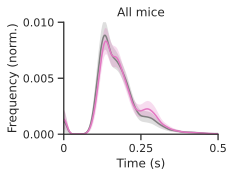

In [110]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior, var='RT', split='drug', kind='hist')
plt.title('All mice')
plt.gca().get_legend().remove()
print(plt.gca().get_ylim())
plt.yticks((0, 0.005, 0.01))
plt.ylim(0, 0.01)

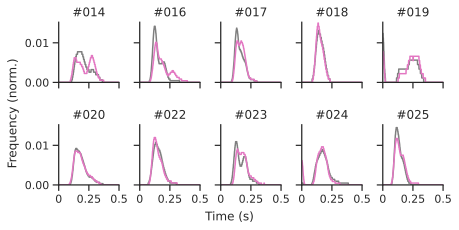

In [111]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[0]/2)
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='RT', split='drug', kind='hist', figsize=figsize)

RT: t = -1.234, p = 0.249


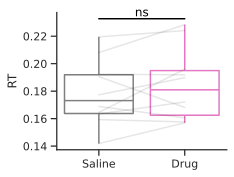

In [86]:
# Stats
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='RT', figsize=figsize)

#### ILD

In [17]:
figsize = fig_size(n_cols=2)

##### All trials

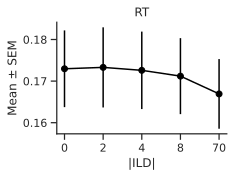

In [18]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='RT')

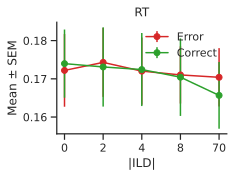

In [19]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='RT', split='outcome')

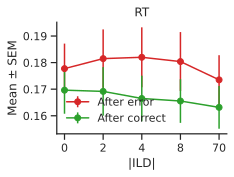

In [20]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='RT', split='prev_out')

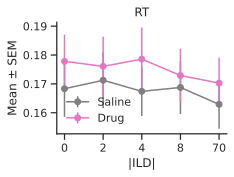

In [21]:
# Split by drug
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='RT', split='drug')

##### Saline

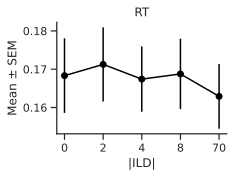

In [22]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='RT')

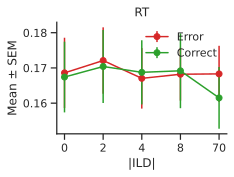

In [23]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='RT', split='outcome')

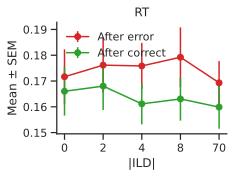

In [24]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='RT', split='prev_out')

##### Drug

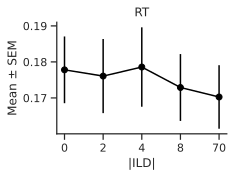

In [25]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='RT')

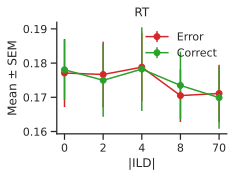

In [26]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='RT', split='outcome')

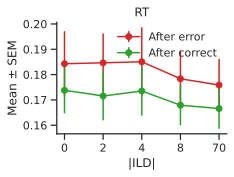

In [27]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='RT', split='prev_out')

#### Model

Fitting GLM with Gaussian family for RT...
Including Drug and its interaction with p(eng) as a predictor...
Fitting model for subject 014 (3733)...
Dropping 0 sessions with <50 trials:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: RT       
No. Observations: 3683    Method:             REML     
No. Groups:       14      Scale:              0.0045   
Min. group size:  114     Log-Likelihood:     4644.6634
Max. group size:  292     Converged:          Yes      
Mean group size:  263.1                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.343    0.016 21.270 0.000  0.311  0.375
Choice        0.009    0.001  6.546 0.000  0.006  0.011
Hit           0.002    0.004  0.503 0.615 -0.006  0.009
BeforeError   0.008    0.002  3.279 0.001  0.003  0.012
AfterError    0.027    0.002 11.786 0.00

Text(0, 0.5, 'Weight (s)')

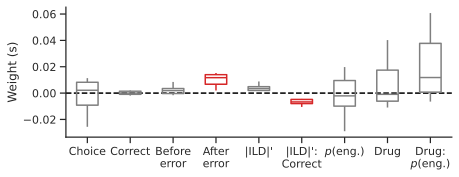

In [213]:
figsize = (fig_size(n_cols=1)[0], fig_size(n_cols=2)[1])
var = 'RT'
df_params, df_p = model_licks(df_behavior, var=var, drug=True, me=True)
plot_model_licks(df_params, df_p, figsize=figsize)
plt.gca().title.set_visible(False)
plt.ylabel('Weight (s)')

### Lick rate

In [238]:
median_nlicks_saline = df_behavior[df_behavior.Drug==0].nLicks.median()
mad_nlicks_saline = median_abs_deviation(df_behavior[df_behavior.Drug==0].nLicks, scale=1)
print(f'RT saline (median ± m.a.d.): {np.round(median_nlicks_saline, 3)} ± {np.round(mad_nlicks_saline, 3)} s')

median_nlicks_drug = df_behavior[df_behavior.Drug==1].nLicks.median()
mad_nlicks_drug = median_abs_deviation(df_behavior[df_behavior.Drug==1].nLicks, scale=1)
print(f'RT drug (median ± m.a.d.): {np.round(median_nlicks_saline, 3)} ± {np.round(mad_nlicks_drug, 3)} s')

RT saline (median ± m.a.d.): 5.0 ± 2.0 s
RT drug (median ± m.a.d.): 5.0 ± 2.0 s


(0.0, 0.4221264367816092)


(0.0, 0.5)

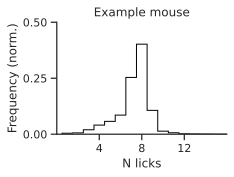

In [147]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Hit==1][df_behavior.Subject==subject], var='nLicks', smooth=True, z=False, density=False, sem=True)
plt.title('Example mouse')
print(plt.gca().get_ylim())
plt.yticks((0, 0.25, 0.5))
plt.ylim(0, 0.5)

(0.0, 0.20241890477851412)


(0.0, 0.3)

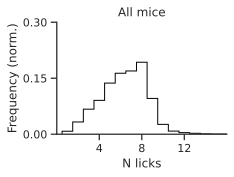

In [146]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Hit==1], var='nLicks', smooth=True, z=False, density=False, sem=True)
plt.title('All mice')
print(plt.gca().get_ylim())
plt.yticks((0, 0.15, 0.3))
plt.ylim(0, 0.3)

(0.0, 0.49073107049608355)


(0.0, 0.5)

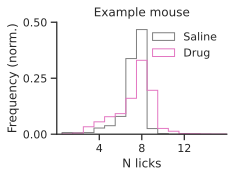

In [145]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Hit==1][df_behavior.Subject==subject], var='nLicks', split='drug', kind='hist')
plt.title('Example mouse')
print(plt.gca().get_ylim())
plt.yticks((0, 0.25, 0.5))
plt.ylim(0, 0.5)

(0.0, 0.2654561204771107)


(0.0, 0.3)

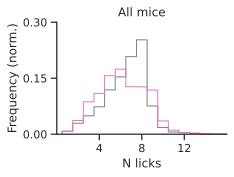

In [144]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='drug', kind='hist')
plt.title('All mice')
plt.legend().remove()
print(plt.gca().get_ylim())
plt.yticks((0, 0.15, 0.3))
plt.ylim(0, 0.3)

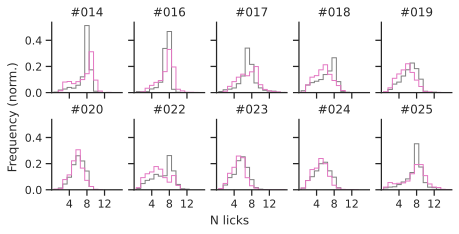

In [142]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[0]/2)
plot_licks_per_subject(df_behavior[df_behavior.Hit==1], plot_func=plot_licks_split, var='nLicks', split='drug', kind='hist', figsize=figsize)

nLicks: t = 3.010, p = 0.015


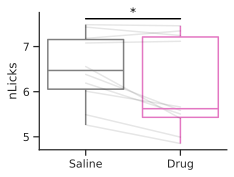

In [143]:
# Stats
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior[df_behavior.Hit==1], var_name='nLicks', figsize=figsize)

#### ILD

In [35]:
figsize = fig_size(n_cols=2)

##### All trials

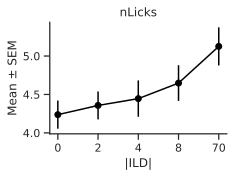

In [36]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='nLicks')

This is simply reflecting the psyschometric behavior: the higher the ILD, the more correct choices, the more licks.

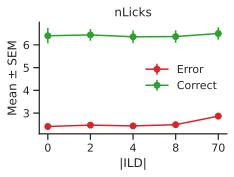

In [37]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='nLicks', split='outcome')

Since now on, current outcome will always be split

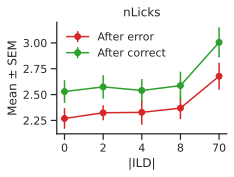

In [38]:
# Split by previous outcome (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==0], var='nLicks', split='prev_out')

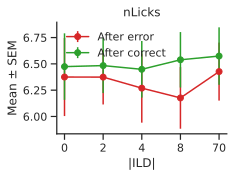

In [39]:
# Split by previous outcome (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='prev_out')

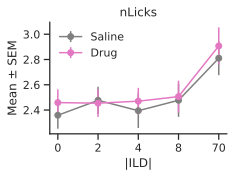

In [40]:
# Split by drug (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==0], var='nLicks', split='drug')

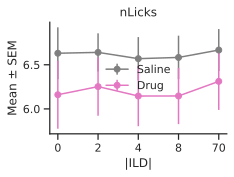

In [41]:
# Split by drug (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='drug')

##### Saline

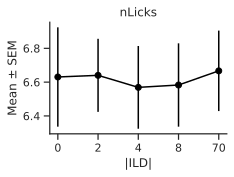

In [42]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0][df_behavior.Hit==1], var='nLicks')

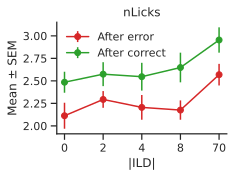

In [43]:
# Split by previous outcome (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0][df_behavior.Hit==0], var='nLicks', split='prev_out')

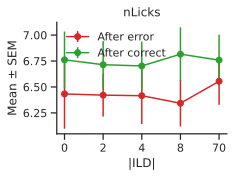

In [44]:
# Split by previous outcome (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0][df_behavior.Hit==1], var='nLicks', split='prev_out')

##### Drug

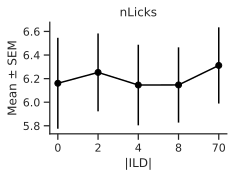

In [45]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1][df_behavior.Hit==1], var='nLicks')

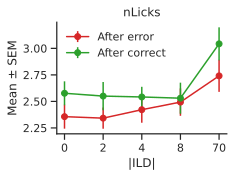

In [46]:
# Split by previous outcome (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1][df_behavior.Hit==0], var='nLicks', split='prev_out')

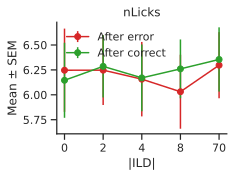

In [47]:
# Split by previous outcome (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1][df_behavior.Hit==1], var='nLicks', split='prev_out')

#### Model

Fitting GLM with Poisson family for nLicks...
Including Drug and its interaction with p(eng) as a predictor...
Fitting model for subject 014 (3733)...
Dropping 0 sessions with <50 trials:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 nLicks   No. Observations:                 2222
Model:                            GLM   Df Residuals:                     2214
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4907.6
Date:                Wed, 04 Feb 2026   Deviance:                       1365.4
Time:                        16:29:37   Pearson chi2:                 1.18e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02451
Covariance Type:            nonrobust                                         
                 coef 

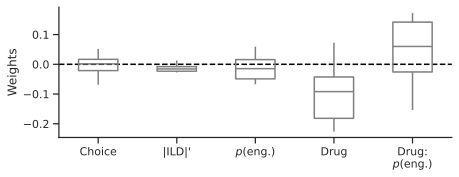

In [214]:
figsize = (fig_size(n_cols=1)[0], fig_size(n_cols=2)[1])
var = 'nLicks'
df_params, df_p = model_licks(df_behavior, var=var, drug=True, me=True)
plot_model_licks(df_params, df_p, figsize=figsize)
plt.gca().title.set_visible(False)

### ILI

In [224]:
mean_ili_saline = df.ILI.mean()
std_ili = df.ILI.std()
print(f'RT mean ± std.: {np.round(mean_ili, 3)} ± {np.round(std_ili, 3)} s')

RT mean ± std.: 0.116 ± 0.045 s


In [237]:
mean_ili_saline = df_behavior[df_behavior.Drug==0].ILI.mean()
std_ili_saline = df_behavior[df_behavior.Drug==0].ILI.std()
print(f'ILI saline (mean ± s.e.m.): {np.round(mean_ili_saline, 3)} ± {np.round(std_ili_saline, 3)} s')

mean_ili_drug = df_behavior[df_behavior.Drug==1].ILI.mean()
std_ili_drug = df_behavior[df_behavior.Drug==1].ILI.std()
print(f'ILI saline (mean ± s.e.m.): {np.round(mean_ili_drug, 3)} ± {np.round(std_ili_drug, 3)} s')

ILI saline (mean ± s.e.m.): 0.124 ± 0.05 s
ILI saline (mean ± s.e.m.): 0.108 ± 0.039 s


(0.0, 0.020435794372752274)


(0.0, 0.025)

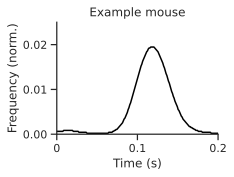

In [191]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Subject==subject], var='ILI', smooth=True, z=False, density=False, sem=True)
plt.title('Example mouse')
print(plt.gca().get_ylim())
plt.yticks((0, 0.01, 0.02))
plt.ylim(0, 0.025)

(0.0, 0.022489185764830655)


(0.0, 0.025)

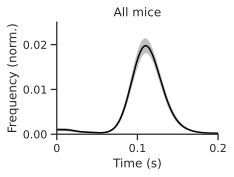

In [192]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior, var='ILI', smooth=True, z=False, density=False, sem=True)
plt.title('All mice')
print(plt.gca().get_ylim())
plt.yticks((0, 0.01, 0.02))
plt.ylim(0, 0.025)

(0.0, 0.02212012550425818)


(0.0, 0.025)

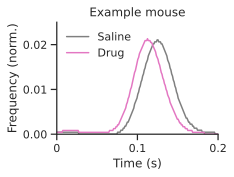

In [197]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Subject==subject], var='ILI', split='drug', kind='hist')
plt.title('Example mouse')
plt.legend(loc='upper left')
print(plt.gca().get_ylim())
plt.yticks((0, 0.01, 0.02))
plt.ylim(0, 0.025)

(0.0, 0.023707157737634287)


(0.0, 0.025)

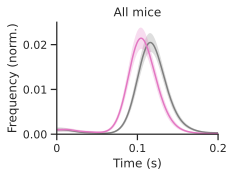

In [194]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior, var='ILI', split='drug', kind='hist')
plt.title('All mice')
plt.legend().remove()
print(plt.gca().get_ylim())
plt.yticks((0, 0.01, 0.02))
plt.ylim(0, 0.025)

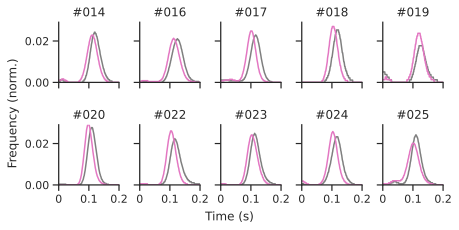

In [195]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[0]/2)
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='ILI', split='drug', kind='hist', figsize=figsize)

ILI: t = 11.746, p = 0.000


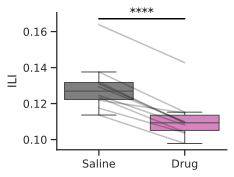

In [54]:
# Stats
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='ILI', figsize=figsize)

#### ILD

In [55]:
figsize = fig_size(n_cols=2)

##### All trials

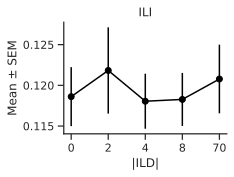

In [56]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='ILI')

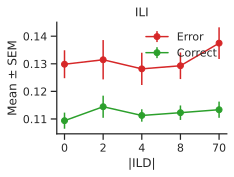

In [57]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='ILI', split='outcome')

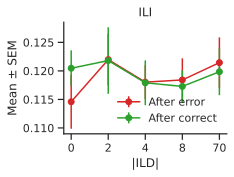

In [58]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='ILI', split='prev_out')

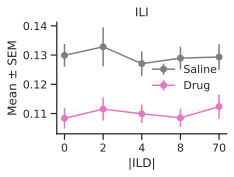

In [59]:
# Split by drug
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='ILI', split='drug')

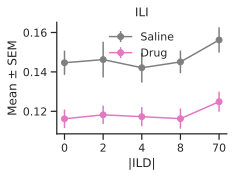

In [60]:
# Split by drug
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==0], var='ILI', split='drug')

##### Saline

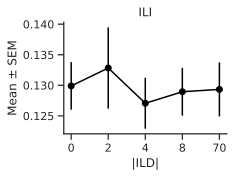

In [61]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='ILI')

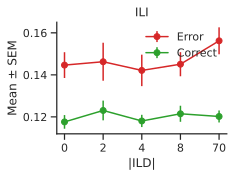

In [62]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='ILI', split='outcome')

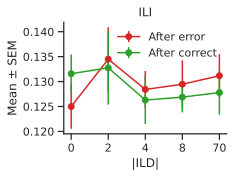

In [63]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='ILI', split='prev_out')

##### Drug

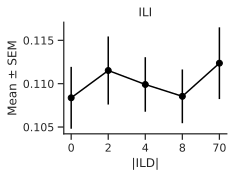

In [64]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='ILI')

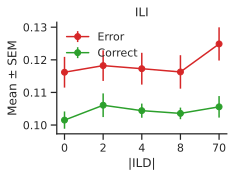

In [65]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='ILI', split='outcome')

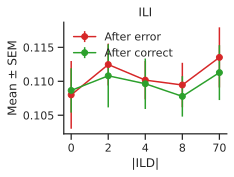

In [66]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='ILI', split='prev_out')

#### Model

Fitting GLM with Gaussian family for ILI...
Including Drug and its interaction with p(eng) as a predictor...
Fitting model for subject 014 (3733)...
Dropping 0 sessions with <50 trials:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ILI      
No. Observations: 3515    Method:             REML     
No. Groups:       14      Scale:              0.0012   
Min. group size:  103     Log-Likelihood:     6717.1282
Max. group size:  286     Converged:          Yes      
Mean group size:  251.1                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.135    0.005 25.817 0.000  0.125  0.145
Choice       -0.002    0.001 -2.390 0.017 -0.003 -0.000
Hit          -0.020    0.002 -9.646 0.000 -0.024 -0.016
BeforeError   0.002    0.001  1.668 0.095 -0.000  0.004
AfterError    0.004    0.001  3.303 0.0

Text(0, 0.5, 'Weight (s)')

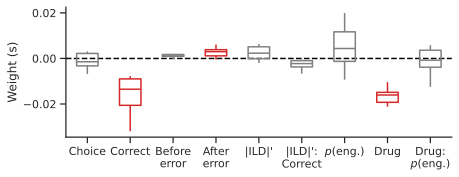

In [215]:
figsize = (fig_size(n_cols=1)[0], fig_size(n_cols=2)[1])
var = 'ILI'
df_params, df_p = model_licks(df_behavior, var=var, drug=True, me=True)
plot_model_licks(df_params, df_p,    figsize=figsize)
plt.gca().title.set_visible(False)
plt.ylabel('Weight (s)')

In [ ]:
def plot_ild_dist_mean_eng_drug(var='RT'):

    # Define conditions and titles
    conditions = [
        (0, 0),  # Disengaged - Saline
        (0, 1),  # Disengaged - Drug
        (1, 0),  # Engaged - Saline
        (1, 1)  # Engaged - Drug
    ]

    # Compute global y-limits
    all_means = []
    for engaged, drug in conditions:
        df = df_behavior[(df_behavior.Engaged==engaged) & (df_behavior.Drug==drug)]
        for ild in df_behavior.absILD.unique():
            all_means.append(df[df.absILD==ild][var].mean())
    y_min, y_max = min(all_means), max(all_means)
    y_ticks = np.linspace(y_min, y_max, 3)

    # Create 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

    # Loop over conditions
    for engaged, drug in conditions:
        ax = axes[engaged, drug]
        plt.sca(ax)
        plot_ild_dist_mean(df_behavior[(df_behavior.Engaged == engaged) & (df_behavior.Drug == drug)], var=var)
        plt.ylim(None, y_max)
        # plt.yticks(y_ticks)

    # Set row labels
    axes[0, 0].set_ylabel('Disengaged')
    axes[1, 0].set_ylabel('Engaged')

    # Set column labels
    axes[0, 0].set_title('Saline')
    axes[0, 1].set_title('Drug')

    # Remove xlabels in 1st row
    axes[0, 0].set_xlabel('')
    axes[0, 1].set_xlabel('')

    # Remove titles in 2nd row
    axes[1, 0].set_title('')
    axes[1, 1].set_title('')

    # Remove ylabels in 2nd column
    axes[0, 1].set_ylabel('')
    axes[1, 1].set_ylabel('')

    plt.suptitle('Mean ' + var)


def test(var='RT'):
    abs_ilds = sorted(df_behavior.absILD.unique())
    x = np.arange(len(abs_ilds))
    conditions = [
        (0, 0, 'tab:gray', '--', 'Dis.-Sal.'),
        # (0, 1, 'tab:pink', '--', 'Dis.-Drug'),
        (1, 0, 'tab:gray', '-', 'Eng.-Sal.'),
        # (1, 1, 'tab:pink', '-', 'Eng.-Drug')
    ]

    plt.figure(figsize=figsize)
    for engaged, drug, color, ls, label in conditions:
        df = df_behavior[(df_behavior.Engaged==engaged) & (df_behavior.Drug==drug)]
        means = [df[df.absILD==ild][var].mean() for ild in abs_ilds]
        sems = [df[df.absILD==ild][var].sem() for ild in abs_ilds]
        plt.errorbar(x, means, yerr=sems, marker='o', color=color, ls=ls, label=label)

    plt.xticks(x, [int(ild) for ild in abs_ilds])
    plt.xlabel('|ILD|')
    plt.ylabel(var)
    plt.legend()
    sns.despine()

In [ ]:
plot_ild_dist_mean_eng_drug(var='RT')
test(var='RT')

plot_ild_dist_mean_eng_drug(var='nLicks')
test(var='nLicks')

plot_ild_dist_mean_eng_drug(var='ILI')
test(var='ILI')

# Psychometrics

In [58]:
# Identify outliers per condition (same as Seaborn)
def remove_outliers(df, group_col, value_col):
    cleaned = []
    for name, group in df.groupby(group_col):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        cleaned.append(group[(group[value_col] >= lower) & (group[value_col] <= upper)])
    return pd.concat(cleaned, axis=0)


def compare_psych_params(params, param_name, **kwargs):
    """
    Compare the parameters of the saline and drug conditions.
    """

    subject = np.tile(np.arange(len(params) // 2), 2)
    params['subject'] = subject
    var_mean = params.groupby('drug')[param_name].mean()
    var_sem = params.groupby('drug')[param_name].sem()

    plt.figure(constrained_layout=True, **kwargs)

    # Plot boxplot
    sns.boxplot(data=params, x='drug', y=param_name, hue='drug', palette=['tab:gray', 'tab:pink'], showfliers=False, legend=False, showcaps=False, fill=False)
    # sns.swarmplot(data=params, x='drug', y=param_name, color='k', legend=False)

    # Plot paired lines
    params_no_outliers = remove_outliers(params, 'drug', param_name)  # Clean outliers
    sns.lineplot(data=params_no_outliers, x='drug', y=param_name, hue='subject', marker='none', palette=['gray'] * int(len(params)/2), alpha=0.1, legend=False)
    # Plot mean and SEM
    # plt.errorbar(x=var_mean.index, y=var_mean.values, yerr=var_sem.values, fmt='-o', color='k')

    # plt.title(var_name)
    plt.ylabel(param_name)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))  # Set a global formatter for y-axis ticks for equal sized plots
    plt.xticks([0, 1], ['S', 'D'])
    plt.xlabel('')
    sns.despine()

    # Add stats
    saline = params[params['drug'] == 0][param_name]
    drug = params[params['drug'] == 1][param_name]
    t_stat, p_val = ttest_rel(saline, drug)
    print(f"{param_name}: t = {t_stat:.3f}, p = {p_val:.3f}")
    add_star_between(p_val)

## Probability choose RIGHT

In [124]:
kind = 'prob_right'
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])

### Single animals

Mouse 014
Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Mouse 016
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Mouse 017
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Mouse 018
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Mouse 019
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Mouse 020
Removed 2060 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2060 trials from session start (AW and Warm Up trials)
Tota

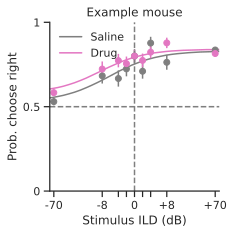

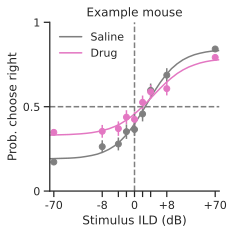

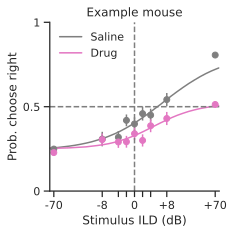

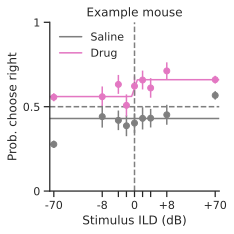

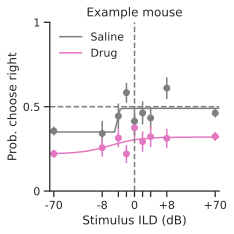

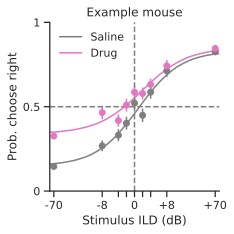

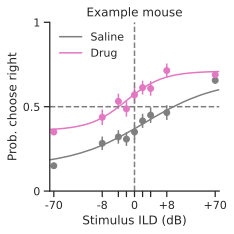

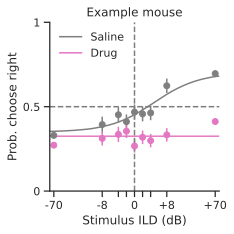

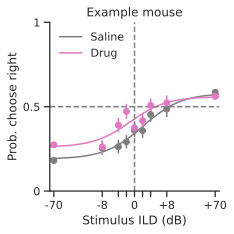

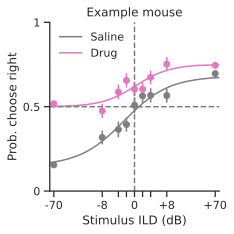

In [113]:
for animal in animals:
    print(f'Mouse {animal}')
    plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind, figsize=figsize)

### Mean across animals

Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2060 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2401 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2337 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2173 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2280 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2836 trials from session start (AW and W

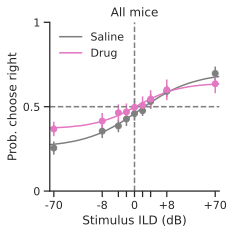

In [125]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind, figsize=figsize)

#### Stats

sensitivity: t = 0.007, p = 0.994
bias: t = 0.741, p = 0.477
lr_right: t = -1.070, p = 0.312
lr_left: t = -1.065, p = 0.315
lapses: t = -1.079, p = 0.309


Text(0, 0.5, 'Lapses')

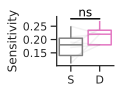

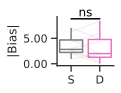

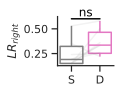

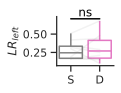

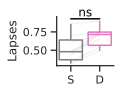

In [126]:
figsize = fig_size(n_cols=4)
params['bias'] = abs(params['bias'])  # Use absolute bias
compare_psych_params(params, 'sensitivity', figsize=figsize); plt.ylabel('Sensitivity')
compare_psych_params(params, 'bias', figsize=figsize); plt.ylabel('|Bias|')
compare_psych_params(params, 'lr_right', figsize=figsize); plt.ylabel(r'$LR_{right}$')
compare_psych_params(params, 'lr_left', figsize=figsize); plt.ylabel(r'$LR_{left}$')
params['lapses'] = (params['lr_right'] + params['lr_left'])  # Total lapse rates
compare_psych_params(params, 'lapses', figsize=figsize); plt.ylabel('Lapses')

## Probability choose REPEAT

In [117]:
kind = 'prob_rep'
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])

### Single animals

Mouse 014
Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Mouse 016
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Mouse 017
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Mouse 018
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Mouse 019
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Mouse 020
Removed 2060 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2060 trials from session start (AW and Warm Up trials)
Tota

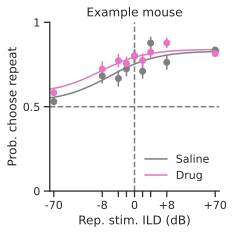

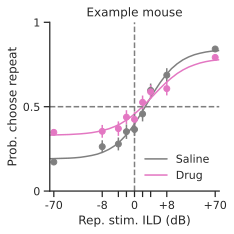

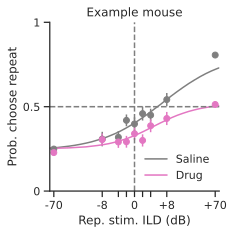

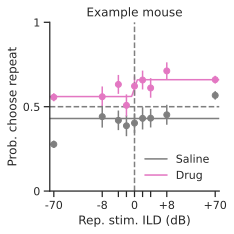

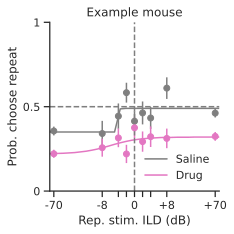

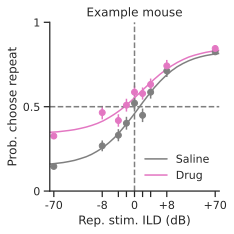

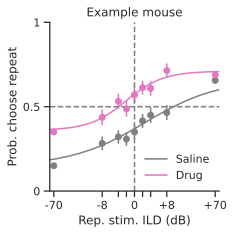

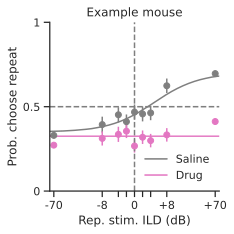

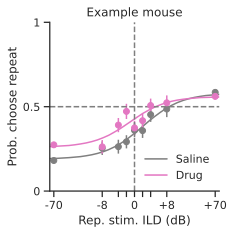

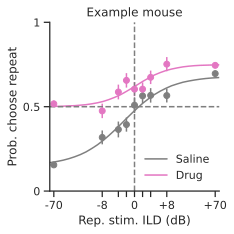

In [118]:
for animal in animals:
    print(f'Mouse {animal}')
    plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind, figsize=figsize)

### Mean across animals

Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2060 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2401 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2337 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2173 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2280 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2836 trials from session start (AW and W

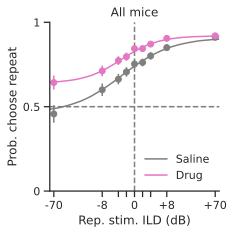

In [119]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind, figsize=figsize)

#### Stats

sensitivity: t = -2.073, p = 0.068
bias: t = 0.217, p = 0.833
lr_rep: t = -7.302, p = 0.000
lr_alt: t = 0.434, p = 0.675
lapses: t = -8.905, p = 0.000


Text(0, 0.5, 'Lapses')

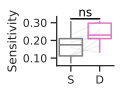

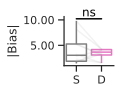

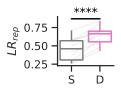

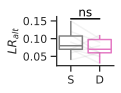

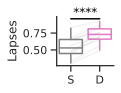

In [123]:
figsize = fig_size(n_cols=4)
params['bias'] = abs(params['bias'])  # Use absolute bias
compare_psych_params(params, 'sensitivity', figsize=figsize); plt.ylabel('Sensitivity')
compare_psych_params(params, 'bias', figsize=figsize); plt.ylabel('|Bias|')
compare_psych_params(params, 'lr_rep', figsize=figsize); plt.ylabel(r'$LR_{rep}$')
compare_psych_params(params, 'lr_alt', figsize=figsize); plt.ylabel(r'$LR_{alt}$')
params['lapses'] = (params['lr_rep'] + params['lr_alt'])  # Total lapse rates
compare_psych_params(params, 'lapses', figsize=figsize); plt.ylabel('Lapses')

# Kernels
Full GLM of behavior

In [129]:
# Parameters
residuals = True
zscore = False
drug = None
trial_lag = 10
iterations = 1
save = False
figsize = fig_size(n_cols=2)

experiments = ['2AFC_6']
# hk = get_mean_hk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_hk(experiment=experiments, animal=None, drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Filtering in drug sessions...
Getting choice history of trial lag 10
Getting choice history of trial lag 9
Getting choice history of trial lag 8
Getting choice history of trial lag 7
Getting choice history of trial lag 6
Getting choice history of trial lag 5
Getting choice history of trial lag 4
Getting choice history of trial lag 3
Getting choice history of trial lag 2
Getting choice history of trial lag 1
get_fk took 4.97 seconds to run
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Filtering in drug sessions...
Getting choice history of trial lag 10
Getting choice history of trial lag 9
Getting choice history of trial lag 8
Getting choice history of trial lag 7
Getting choice history of trial lag 6
Getting choice history of trial lag 5
Getting choice history of trial lag 4
Getting choice history of trial lag 3
Getting choice history of trial lag 2
Getting choice history o

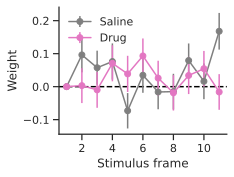

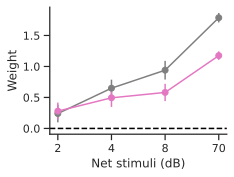

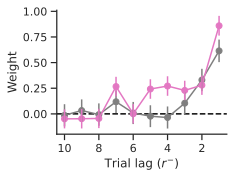

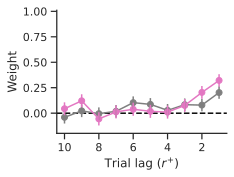

In [132]:
# Example subject
figsize = fig_size(n_cols=2)
plot_drug_fk(experiment='2AFC_6', animal='016', drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

Cherry picking for experiment: 2AFC_6
Number of responded trials in data collection (with evidences):
11: 0 trials
14: 10896 trials
15: 3739 trials
16: 11058 trials
17: 12772 trials
18: 7451 trials
19: 8305 trials
20: 10752 trials
21: 0 trials
22: 10453 trials
23: 10169 trials
24: 10118 trials
25: 9890 trials


Subjects left behind (never learnt):
11: 0 trials
21: 0 trials


Removed 2773 trials from session start (AW and Warm Up trials)
Total:11k trials
Removed 1562 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2701 trials from session start (AW and Warm Up trials)
Total:10k trials
Removed 2836 trials from session start (AW and Warm Up trials)
Total:9k trials
Removed 1852 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2551 trials from session start (AW and Warm Up trials)
Total:8k trials
Removed 2060 trials from session start (AW and Warm Up trials)
Total:7k trials
Removed 2401 trials from session start (AW and Warm Up trials)
Tota

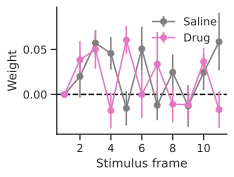

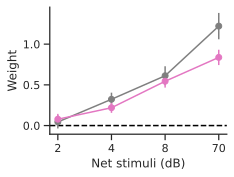

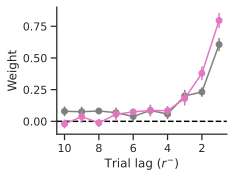

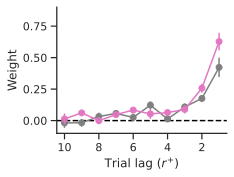

In [136]:
# Mean all mice
figsize = fig_size(n_cols=2)
plot_drug_fk(experiment=experiments, animal=None, iterations=iterations, save=save, figsize=figsize)

# GLM HMM

# Serial dependence

Serial dependence requires a continuous readout of behavioral responses. As choices are binary (left/right), other readouts are needed. Let's try with reaction times (RT) and lick rate (nLicks)

In [ ]:
df = df_behavior

loc = df.columns.get_loc('Side') + 1
df.insert(loc, 'PreviousSide', df['Side'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousSide') + 1
df.insert(loc, 'RepSide', (df['Side'] == df['PreviousSide']).astype(int))  # Add repeating stimulus column
loc = df.columns.get_loc('ILD') + 1
df.insert(loc, 'PreviousILD', df['ILD'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousILD') + 1
df.insert(loc, 'DeltaILD', df.PreviousILD - df.ILD)  # Add previous stimulus side column
loc = df.columns.get_loc('DeltaILD') + 1
df.insert(loc, 'absDeltaILD', abs(df.DeltaILD))  # Add previous stimulus side column

# Filter data
df = df[df.Task == 'FD'].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)
df = df[df.Hit == 1].reset_index(drop=True)

# loc = df.columns.get_loc('nLicksRight') + 1  # Added to add_licks function
# df.insert(loc, 'nLicks', np.where(df['Side'] == 0, df['nLicksLeft'], df['nLicksRight']))  # Add number of licks column

# Center at 0 variables of interest
df.nLicks = df.nLicks - df.nLicks.mean()  # Substract its mean to nLicks
df.RT = df.RT - df.RT.mean()  # Substract its mean to RT
df.RT2 = df.RT2 - df.RT2.mean()  # Substract its mean to RT2

df.head()

In [ ]:
# Check value range of DeltaILD for binning later
np.array(sorted(df.DeltaILD.unique()))

In [ ]:
def plot_binned_deltaILD(var='RT', absolute=False):
    """
    Plot binned deltaILD distribution.
    :param var: variable to plot
    :param abs: if True, plot absolute values of deltaILD
    :return:
    """

    # Set bin edges
    if absolute:
        bins = [0, 5, 10, 20, 70, 80, 140]
        col_name = 'absDeltaILD'
        xlabel = 'abs(ΔILD)'
    else:
        bins = [-140, -80, -70, -20, -10, -5 , 5, 10, 20, 70, 80, 140]
        xlabel = 'ΔILD'
        col_name = 'DeltaILD'

    # Create bin labels ( as the bin spacing is not continuous)
    labels = [f"{bins[i]}:{bins[i+1]}" for i in range(len(bins)-1)]

    # Bin the data
    df['ILDbin'] = pd.cut(df[col_name], bins=bins, labels=labels, include_lowest=True)

    # Group and compute means
    mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()

    # Plot
    plt.figure(constrained_layout=True)
    plt.bar(mean_licks['ILDbin'], mean_licks[var], color='tab:gray')
    plt.xlabel(xlabel)
    plt.ylabel(var)
    plt.xticks(rotation=45)
    plt.title(f'{var} by {xlabel}')
    sns.despine()

### Measured as Reaction Times (RTs)

In [ ]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].RT, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].RT, label='alt_stim', color='tab:brown')
plt.title('RT distribution')
# plt.legend(frameon=False)
sns.despine()

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='RT', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')

# Run t-test
var_name = 'RT'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

In [ ]:
# Plot the RT by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('RT')
plt.title('RT by ΔILD')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=False)

##### Absolute ΔILD

In [ ]:
# Plot the RT by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('RT')
plt.title('RT by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=True)

### Measured as N licks

In [ ]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].nLicks, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].nLicks, label='alt_stim', color='tab:brown')
plt.title('N licks distribution')
# plt.legend(frameon=False)

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='nLicks', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')
sns.despine()

# Run t-test
var_name = 'nLicks'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

In [ ]:
# Plot the number of licks by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('nLicks')
plt.title('nLicks by ΔILD')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=False)

##### Absolute ΔILD

In [ ]:
# Plot the number of licks by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('nLicks')
plt.title('nLicks by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=True)

# Save all notebook's figures

In [218]:
# Whole notebook ouputs (no input or prompt, only Markdown and figures)
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF

# Export all figures
save_notebook_files('notebook.ipynb')

Saved 100 images to notebook_files/
